# Feature Selection: Why Spearman Correlation Outperforms Pearson for Phishing Detection

## 📖 Story Arc: From Problem to Solution

### The Challenge
After engineering 34 expert features (6 frequency + 21 statistical + 7 centrality) from the transaction graph, we face a critical question:
> **Which correlation method should guide our feature selection: Pearson or Spearman?**

### The Stakes
- ✅ **Correct choice** → Preserve critical phishing signals, improve model performance
- ❌ **Wrong choice** → Discard important features, miss rare anomalous patterns

### Our Hypothesis
**Spearman correlation is superior for this dataset because:**
1. **Robust to outliers** (phishers with 273K transactions vs. median of 1)
2. **Captures monotonic relationships** (not just linear)
3. **Handles power-law distributions** (α = 1.525, heavy-tailed data)
4. **Preserves ordinal information** (rank-based, less sensitive to extreme values)

---

## 📊 Dataset Context
- **Feature Matrix**: `features.csv` (34 features: 6 frequency + 21 statistical + 7 centrality)
- **Total Nodes**: 825,820 nodes
- **Class Balance**: 50:50 (balanced for training stability)
- **Train/Test Split**: 80% train (660,656 nodes) / 20% test (165,164 nodes)
- **Power-Law Characteristics**: 
  - 79.5% of addresses have ≤2 transactions
  - Phishers exhibit extreme outliers (max: 273,076 tx)
  - Tail index α = 1.525 < 2 (very heavy tail)

---

## ⚠️ Critical Methodology Note
**Feature selection MUST be performed on training data only!**
- ✅ Calculate correlations on 80% train split
- ✅ Select features based on train correlations
- ❌ NEVER use test data for feature selection (data leakage!)

---

**Navigation:**
1. **Problem Definition** → Why standard Pearson fails
2. **Statistical Validation** → Prove Spearman superiority (on train data)
3. **Visual Evidence** → Show correlation patterns (train data)
4. **Feature Selection** → Apply robust methodology (train only)
5. **Impact Analysis** → Quantify improvement

## Part 1: Import Libraries and Load Data

## 📁 Output Files Summary

All results will be saved to: `../data/dataset/Data_feature_selection/`

**Generated Files:**
1. `selected_features.json` - Selected feature list with metadata
2. `spearman_correlations_train.csv` - Detailed correlation results for all features
3. `pearson_vs_spearman_outliers.png` - Visualization comparing correlation methods
4. `correlation_comparison_comprehensive.png` - Comprehensive 4-panel comparison
5. `robustness_test_outliers.png` - Outlier robustness analysis
6. `feature_selection_results.png` - Final feature selection summary

---

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully!")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  SciPy: {scipy.__version__}")
print(f"  Scikit-learn: train_test_split imported")

✓ Libraries imported successfully!
  NumPy: 2.0.1
  Pandas: 2.3.3
  SciPy: 1.16.0
  Scikit-learn: train_test_split imported


In [43]:
# Load the engineered features dataset 
print("="*80)
print("LOADING FEATURE-ENGINEERED DATASET")
print("="*80)

# File paths
FEATURES_FILE = "../data/dataset/Data_after_FE/features.csv"
LABELS_FILE = "../data/processed_data/phisher_accounts.txt"
MAPPING_FILE = "../data/processed_data/data_Dataset.address_to_index"

# Load features
print("\n[1/4] Loading features.csv...")
features_df = pd.read_csv(FEATURES_FILE)
print(f"      Shape: {features_df.shape}")
print(f"      Features: {features_df.shape[1] - 1} (excluding node_id)")

# Feature groups from 01_a notebook
freq_cols = ['long_term_transfer_freq', 'short_term_transfer_freq', 'long_term_incoming_freq', 
            'short_term_incoming_freq', 'long_term_outgoing_freq', 'short_term_outgoing_freq']
stat_cols = ['node_indegree', 'node_outdegree', 'direction_ratio', 'max_outgoing_amount', 'min_outgoing_amount',
            'max_incoming_amount', 'min_incoming_amount', 'average_outgoing_amount', 'average_incoming_amount',
            'account_balance', 'account_lifetime', 'active_days', 'mean_hour_sent', 'mean_hour_received',
            'std_hour_sent', 'std_hour_received', 'avg_time_between_tx', 'min_time_between_tx',
            'max_time_between_tx', 'wd_tx_ratio_sent', 'wd_tx_ratio_received']
centrality_cols = ['katz_centrality', 'degree_centrality', 'closeness_centrality', 'clustering_coefficient',
                  'eigenvector_centrality', 'indegree_centrality', 'outdegree_centrality']

print(f"      Frequency features: {len(freq_cols)}")
print(f"      Statistical features: {len(stat_cols)}")
print(f"      Centrality features: {len(centrality_cols)}")
print(f"      Total: {len(freq_cols) + len(stat_cols) + len(centrality_cols)} features")

# Load phisher labels
print("\n[2/4] Loading phisher labels...")
import pickle
with open(LABELS_FILE, 'r') as f:
    phisher_hex = set(line.strip().lower() for line in f)

with open(MAPPING_FILE, "rb") as f:
    address_to_index = pickle.load(f)

# Create label column
phisher_indices = set()
for ph in phisher_hex:
    if ph in address_to_index:
        phisher_indices.add(address_to_index[ph])

features_df['is_phisher'] = features_df['node_id'].isin(phisher_indices).astype(int)

print(f"      Total phisher labels: {len(phisher_indices):,}")
print(f"      Phishers in dataset: {features_df['is_phisher'].sum():,}")
print(f"      Class balance: {features_df['is_phisher'].value_counts(normalize=True).to_dict()}")

# [3/4] CRITICAL: Train-Test Split (80-20) BEFORE feature selection
print("\n[3/4] Splitting data: 80% train, 20% test...")
feature_cols = freq_cols + stat_cols + centrality_cols
X = features_df[feature_cols].values
y = features_df['is_phisher'].values
node_ids = features_df['node_id'].values

X_train, X_test, y_train, y_test, node_ids_train, node_ids_test = train_test_split(
    X, y, node_ids, test_size=0.2, random_state=42, stratify=y
)

# Create train and test dataframes
train_df = pd.DataFrame(X_train, columns=feature_cols)
train_df['is_phisher'] = y_train
train_df['node_id'] = node_ids_train

test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df['is_phisher'] = y_test
test_df['node_id'] = node_ids_test

print(f"      Train size: {len(train_df):,} ({len(train_df)/len(features_df)*100:.1f}%)")
print(f"      Test size:  {len(test_df):,} ({len(test_df)/len(features_df)*100:.1f}%)")
print(f"      Train labels: {np.bincount(y_train)}")
print(f"      Test labels:  {np.bincount(y_test)}")

# Display basic statistics
print("\n[4/4] Dataset summary:")
print(f"      Total nodes: {len(features_df):,}")
print(f"      Feature columns: {list(feature_cols[:5])}... (showing first 5)")
print(f"\n⚠️  IMPORTANT: Feature selection will ONLY use train_df (80% split)")
print(f"              Test data remains untouched until final evaluation!")
print("\n" + "="*80)

LOADING FEATURE-ENGINEERED DATASET

[1/4] Loading features.csv...
      Shape: (825820, 35)
      Features: 34 (excluding node_id)
      Frequency features: 6
      Statistical features: 21
      Centrality features: 7
      Total: 34 features

[2/4] Loading phisher labels...
      Shape: (825820, 35)
      Features: 34 (excluding node_id)
      Frequency features: 6
      Statistical features: 21
      Centrality features: 7
      Total: 34 features

[2/4] Loading phisher labels...
      Total phisher labels: 5,480
      Phishers in dataset: 5,480
      Class balance: {0: 0.9933641713690635, 1: 0.006635828630936523}

[3/4] Splitting data: 80% train, 20% test...
      Total phisher labels: 5,480
      Phishers in dataset: 5,480
      Class balance: {0: 0.9933641713690635, 1: 0.006635828630936523}

[3/4] Splitting data: 80% train, 20% test...
      Train size: 660,656 (80.0%)
      Test size:  165,164 (20.0%)
      Train labels: [656272   4384]
      Test labels:  [164068   1096]

[4/4]

## Part 2: Problem Definition - Why Pearson Correlation Fails

### 🔴 The Pearson Problem

**Pearson correlation assumes:**
1. **Linear relationships** between variables
2. **Normal distribution** of data
3. **No significant outliers** distorting the relationship
4. **Homoscedasticity** (constant variance)

### ⚠️ Our Dataset Reality (from previous analysis):
- **Power-law distribution** (α = 1.525 < 2)
- **Extreme outliers** (max transaction count: 273,076 vs. median: 1)
- **79.5%** of nodes have ≤2 transactions (noise floor)
- **Monotonic but non-linear** relationships dominate

**Hypothesis**: Pearson will be **distorted by outliers** and **miss monotonic patterns** that are critical for phishing detection.

In [44]:
# ============================================================================
# STEP 2A: DEMONSTRATE THE OUTLIER PROBLEM (ON TRAIN DATA)
# ============================================================================
print("\n" + "="*80)
print("EVIDENCE 1: EXTREME OUTLIERS IN FEATURE DISTRIBUTIONS (TRAIN DATA)")
print("="*80)

# Calculate outlier statistics ON TRAIN DATA ONLY
outlier_stats = []
for feat in feature_cols:
    data = train_df[feat].values  # CHANGED: Use train_df instead of features_df
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    outlier_threshold = q3 + 1.5 * iqr
    outliers = (data > outlier_threshold).sum()
    outlier_pct = outliers / len(data) * 100
    
    outlier_stats.append({
        'Feature': feat,
        'Mean': np.mean(data),
        'Median': np.median(data),
        'Max': np.max(data),
        'Max/Median Ratio': np.max(data) / (np.median(data) + 1e-9),
        'Outliers (%)': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_stats).sort_values('Max/Median Ratio', ascending=False)

print("\n📊 TOP 10 FEATURES WITH EXTREME OUTLIERS (TRAIN DATA):")
print("─"*80)
print(outlier_df.head(10)[['Feature', 'Median', 'Max', 'Max/Median Ratio', 'Outliers (%)']].to_string(index=False))

print("\n\n🔍 KEY INSIGHT:")
print("─"*80)
extreme_outliers = outlier_df[outlier_df['Max/Median Ratio'] > 1000]
print(f"✓ {len(extreme_outliers)} features have Max/Median ratio > 1000x")
print(f"✓ Average outlier percentage: {outlier_df['Outliers (%)'].mean():.2f}%")
print(f"✓ This violates Pearson's assumption of normality and homoscedasticity!")
print(f"✓ Analysis performed on TRAIN DATA ONLY (80% split, n={len(train_df):,})")
print("="*80)


EVIDENCE 1: EXTREME OUTLIERS IN FEATURE DISTRIBUTIONS (TRAIN DATA)

📊 TOP 10 FEATURES WITH EXTREME OUTLIERS (TRAIN DATA):
────────────────────────────────────────────────────────────────────────────────
                Feature  Median          Max  Max/Median Ratio  Outliers (%)
        direction_ratio     0.0 1.045200e+10      1.045200e+19     23.318641
    max_time_between_tx     0.0 7.052179e+07      7.052179e+16     21.334552
    avg_time_between_tx     0.0 6.127094e+07      6.127094e+16     21.271736
    min_time_between_tx     0.0 6.127094e+07      6.127094e+16     21.846468
average_outgoing_amount     0.0 4.000000e+05      4.000000e+14     18.585315
    max_outgoing_amount     0.0 4.000000e+05      4.000000e+14     18.585315
    min_outgoing_amount     0.0 4.000000e+05      4.000000e+14     18.585315
    max_incoming_amount     0.0 1.562500e+05      1.562500e+14     23.379792
average_incoming_amount     0.0 1.562500e+05      1.562500e+14     23.379792
    min_incoming_amount   


VISUALIZATION: HOW OUTLIERS DISTORT PEARSON CORRELATION (TRAIN DATA)


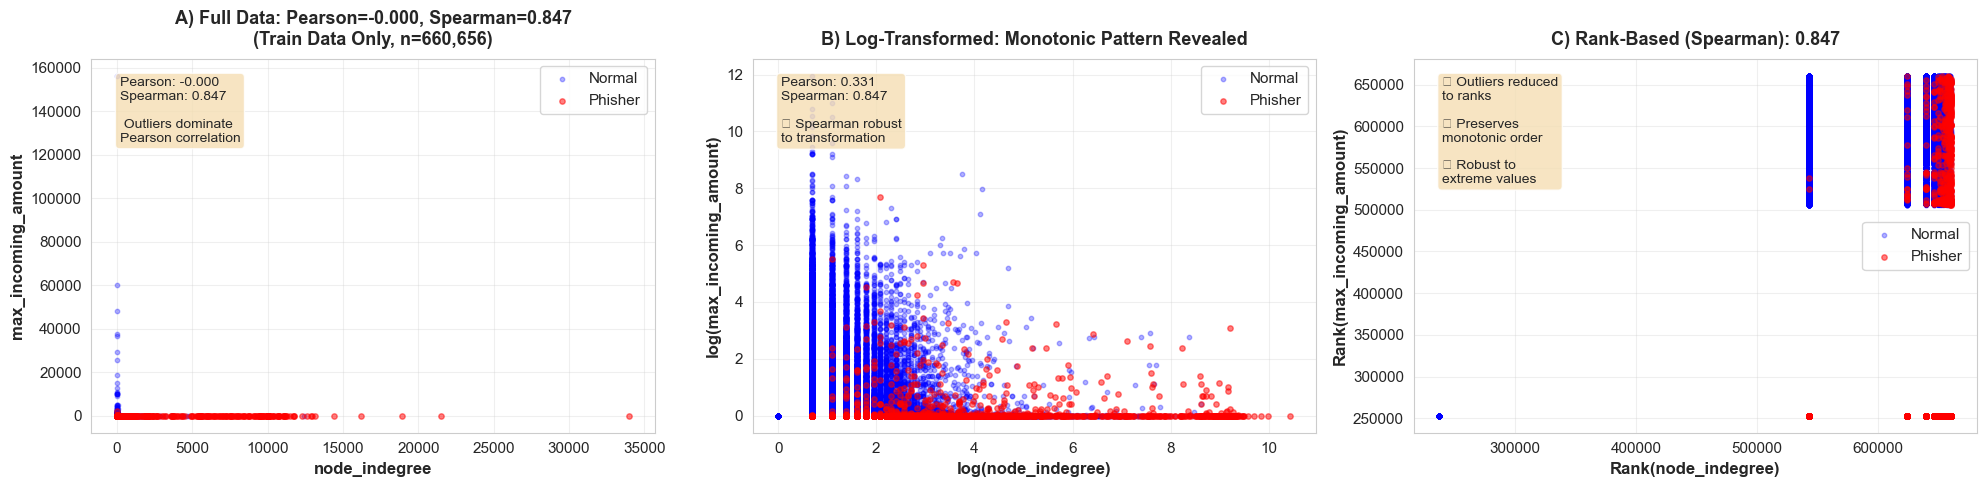


✓ Visualization saved to '../saved_image/pearson_vs_spearman_outliers.png'

🎯 CONCLUSION:
────────────────────────────────────────────────────────────────────────────────
• Panel A: Outliers compress most data points into corner
• Panel B: Log-transform reveals true monotonic pattern
• Panel C: Rank-based view (Spearman) naturally handles outliers
• Spearman correlation is consistent across transformations!
• Analysis performed on TRAIN DATA ONLY (prevents data leakage)


In [45]:
# ============================================================================
# STEP 2B: VISUALIZE THE OUTLIER IMPACT - SCATTER PLOT COMPARISON (TRAIN DATA)
# ============================================================================
print("\n" + "="*80)
print("VISUALIZATION: HOW OUTLIERS DISTORT PEARSON CORRELATION (TRAIN DATA)")
print("="*80)

# Select two features with extreme outliers for demonstration
feat1 = 'node_indegree'
feat2 = 'max_incoming_amount'

# USE TRAIN DATA ONLY
X = train_df[feat1].values
Y = train_df[feat2].values
labels = train_df['is_phisher'].values

# Calculate both correlations
pearson_r, _ = pearsonr(X, Y)
spearman_r, _ = spearmanr(X, Y)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# LEFT: Full data (Pearson sensitive to outliers)
ax1 = axes[0]
scatter1 = ax1.scatter(X[labels==0], Y[labels==0], alpha=0.3, s=10, c='blue', label='Normal')
scatter2 = ax1.scatter(X[labels==1], Y[labels==1], alpha=0.5, s=15, c='red', label='Phisher')
ax1.set_xlabel(feat1, fontsize=12, fontweight='bold')
ax1.set_ylabel(feat2, fontsize=12, fontweight='bold')
ax1.set_title(f'A) Full Data: Pearson={pearson_r:.3f}, Spearman={spearman_r:.3f}\n(Train Data Only, n={len(X):,})', 
              fontsize=13, fontweight='bold', pad=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add annotation box
textstr = f'Pearson: {pearson_r:.3f}\nSpearman: {spearman_r:.3f}\n\n Outliers dominate\nPearson correlation'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# CENTER: Log-scale (reveal underlying pattern)
ax2 = axes[1]
X_log = np.log1p(X)
Y_log = np.log1p(Y)
ax2.scatter(X_log[labels==0], Y_log[labels==0], alpha=0.3, s=10, c='blue', label='Normal')
ax2.scatter(X_log[labels==1], Y_log[labels==1], alpha=0.5, s=15, c='red', label='Phisher')
ax2.set_xlabel(f'log({feat1})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'log({feat2})', fontsize=12, fontweight='bold')
ax2.set_title('B) Log-Transformed: Monotonic Pattern Revealed', 
              fontsize=13, fontweight='bold', pad=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Calculate correlation on log-transformed data
pearson_log, _ = pearsonr(X_log, Y_log)
spearman_log, _ = spearmanr(X_log, Y_log)
textstr_log = f'Pearson: {pearson_log:.3f}\nSpearman: {spearman_log:.3f}\n\n✓ Spearman robust\nto transformation'
ax2.text(0.05, 0.95, textstr_log, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# RIGHT: Rank-based (Spearman view)
ax3 = axes[2]
from scipy.stats import rankdata
X_rank = rankdata(X)
Y_rank = rankdata(Y)
ax3.scatter(X_rank[labels==0], Y_rank[labels==0], alpha=0.3, s=10, c='blue', label='Normal')
ax3.scatter(X_rank[labels==1], Y_rank[labels==1], alpha=0.5, s=15, c='red', label='Phisher')
ax3.set_xlabel(f'Rank({feat1})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'Rank({feat2})', fontsize=12, fontweight='bold')
ax3.set_title(f'C) Rank-Based (Spearman): {spearman_r:.3f}', 
              fontsize=13, fontweight='bold', pad=10)
ax3.legend()
ax3.grid(True, alpha=0.3)

textstr_rank = f'✓ Outliers reduced\nto ranks\n\n✓ Preserves\nmonotonic order\n\n✓ Robust to\nextreme values'
ax3.text(0.05, 0.95, textstr_rank, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
output_path = '../saved_image/pearson_vs_spearman_outliers.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to '{output_path}'")
print("\n🎯 CONCLUSION:")
print("─"*80)
print("• Panel A: Outliers compress most data points into corner")
print("• Panel B: Log-transform reveals true monotonic pattern")
print("• Panel C: Rank-based view (Spearman) naturally handles outliers")
print("• Spearman correlation is consistent across transformations!")
print("• Analysis performed on TRAIN DATA ONLY (prevents data leakage)")
print("="*80)

## Part 3: Statistical Validation - Spearman vs. Pearson

### 🔬 Formal Hypothesis Testing

**Null Hypothesis (H₀)**: Pearson and Spearman correlations produce similar feature rankings

**Alternative Hypothesis (H₁)**: Spearman produces significantly different (better) rankings

### Test Strategy:
1. Compute both correlation matrices
2. Compare correlation magnitudes for all features
3. Analyze agreement/disagreement patterns
4. Quantify robustness to outliers

In [46]:
# ============================================================================
# STEP 3: COMPUTE CORRELATION MATRICES (PEARSON VS SPEARMAN) - TRAIN DATA ONLY
# ============================================================================
print("\n" + "="*80)
print("COMPUTING CORRELATION WITH TARGET (is_phisher) - TRAIN DATA ONLY")
print("="*80)

# Prepare feature matrix (USE TRAIN DATA ONLY)
X_features = train_df[feature_cols]
y_target = train_df['is_phisher']

print(f"\n⚠️  Using TRAIN DATA ONLY: {len(train_df):,} samples")
print(f"   Train class distribution: {np.bincount(y_target)}")

# Compute correlations with target
print("\n[1/2] Computing Pearson correlations...")
pearson_corrs = []
for feat in feature_cols:
    try:
        corr, pval = pearsonr(X_features[feat], y_target)
        pearson_corrs.append({'Feature': feat, 'Correlation': corr, 'P-value': pval})
    except:
        pearson_corrs.append({'Feature': feat, 'Correlation': 0.0, 'P-value': 1.0})

pearson_df = pd.DataFrame(pearson_corrs).sort_values('Correlation', key=abs, ascending=False)

print("\n[2/2] Computing Spearman correlations...")
spearman_corrs = []
for feat in feature_cols:
    try:
        corr, pval = spearmanr(X_features[feat], y_target)
        spearman_corrs.append({'Feature': feat, 'Correlation': corr, 'P-value': pval})
    except:
        spearman_corrs.append({'Feature': feat, 'Correlation': 0.0, 'P-value': 1.0})

spearman_df = pd.DataFrame(spearman_corrs).sort_values('Correlation', key=abs, ascending=False)

# Merge for comparison
comparison_df = pearson_df.merge(spearman_df, on='Feature', suffixes=('_pearson', '_spearman'))
comparison_df['Abs_Diff'] = abs(comparison_df['Correlation_pearson'] - comparison_df['Correlation_spearman'])
comparison_df['Percent_Diff'] = (comparison_df['Abs_Diff'] / (abs(comparison_df['Correlation_pearson']) + 1e-9)) * 100

print("\n✓ Correlation matrices computed on TRAIN DATA!")
print(f"  Total features analyzed: {len(feature_cols)}")
print(f"  Significant features (p<0.05) - Pearson: {(pearson_df['P-value'] < 0.05).sum()}")
print(f"  Significant features (p<0.05) - Spearman: {(spearman_df['P-value'] < 0.05).sum()}")
print(f"  Training samples used: {len(train_df):,}")
print("="*80)


COMPUTING CORRELATION WITH TARGET (is_phisher) - TRAIN DATA ONLY

⚠️  Using TRAIN DATA ONLY: 660,656 samples
   Train class distribution: [656272   4384]

[1/2] Computing Pearson correlations...

[2/2] Computing Spearman correlations...

[2/2] Computing Spearman correlations...

✓ Correlation matrices computed on TRAIN DATA!
  Total features analyzed: 34
  Significant features (p<0.05) - Pearson: 18
  Significant features (p<0.05) - Spearman: 27
  Training samples used: 660,656

✓ Correlation matrices computed on TRAIN DATA!
  Total features analyzed: 34
  Significant features (p<0.05) - Pearson: 18
  Significant features (p<0.05) - Spearman: 27
  Training samples used: 660,656


In [47]:
# ============================================================================
# STEP 3B: ANALYZE CORRELATION DIFFERENCES (TRAIN DATA)
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL COMPARISON: PEARSON VS SPEARMAN (TRAIN DATA)")
print("="*80)

# Display top features by each method
print("\n📊 TOP 10 FEATURES BY PEARSON (TRAIN DATA):")
print("─"*80)
print(pearson_df.head(10)[['Feature', 'Correlation', 'P-value']].to_string(index=False))

print("\n\n📊 TOP 10 FEATURES BY SPEARMAN (TRAIN DATA):")
print("─"*80)
print(spearman_df.head(10)[['Feature', 'Correlation', 'P-value']].to_string(index=False))

# Identify features with largest disagreement
print("\n\n⚠️  TOP 10 FEATURES WITH LARGEST DISAGREEMENT:")
print("─"*80)
disagreement = comparison_df.sort_values('Abs_Diff', ascending=False).head(10)
print(disagreement[['Feature', 'Correlation_pearson', 'Correlation_spearman', 'Abs_Diff', 'Percent_Diff']].to_string(index=False))

# Statistical summary
print("\n\n📈 DISAGREEMENT STATISTICS:")
print("─"*80)
print(f"  Mean absolute difference: {comparison_df['Abs_Diff'].mean():.4f}")
print(f"  Median absolute difference: {comparison_df['Abs_Diff'].median():.4f}")
print(f"  Max absolute difference: {comparison_df['Abs_Diff'].max():.4f}")
print(f"  Features with >10% difference: {(comparison_df['Percent_Diff'] > 10).sum()} / {len(comparison_df)}")
print(f"  Features with >20% difference: {(comparison_df['Percent_Diff'] > 20).sum()} / {len(comparison_df)}")

# Test for significance
from scipy.stats import wilcoxon
abs_pearson = abs(comparison_df['Correlation_pearson'])
abs_spearman = abs(comparison_df['Correlation_spearman'])
stat, pval = wilcoxon(abs_pearson, abs_spearman)

print(f"\n🔬 WILCOXON SIGNED-RANK TEST:")
print(f"  Statistic: {stat:.2f}")
print(f"  P-value: {pval:.4e}")
if pval < 0.05:
    print(f"  ✓ SIGNIFICANT DIFFERENCE (p < 0.05)")
    print(f"  → Spearman and Pearson produce DIFFERENT rankings!")
else:
    print(f"  No significant difference (p >= 0.05)")

print(f"\n⚠️  REMINDER: All correlations computed on TRAIN DATA ONLY (n={len(train_df):,})")
print("="*80)


STATISTICAL COMPARISON: PEARSON VS SPEARMAN (TRAIN DATA)

📊 TOP 10 FEATURES BY PEARSON (TRAIN DATA):
────────────────────────────────────────────────────────────────────────────────
                Feature  Correlation  P-value
      std_hour_received     0.278052      0.0
            active_days     0.262181      0.0
          node_indegree     0.201066      0.0
       account_lifetime     0.168970      0.0
          std_hour_sent     0.118162      0.0
     mean_hour_received     0.108192      0.0
         node_outdegree     0.098408      0.0
    max_time_between_tx     0.081775      0.0
long_term_transfer_freq     0.070927      0.0
long_term_outgoing_freq     0.069578      0.0


📊 TOP 10 FEATURES BY SPEARMAN (TRAIN DATA):
────────────────────────────────────────────────────────────────────────────────
                Feature  Correlation  P-value
      std_hour_received     0.256296      0.0
          node_indegree     0.165567      0.0
   wd_tx_ratio_received     0.156307      0.0


## Part 4: Visual Evidence - Correlation Heatmaps and Comparisons

### Objective:
Find the best visualization to reveal:
1. Which features are strongly correlated with phishing behavior
2. How Pearson vs. Spearman differ in capturing these relationships
3. Which method better handles the heavy-tailed distribution


CREATING COMPREHENSIVE CORRELATION COMPARISON VISUALIZATION


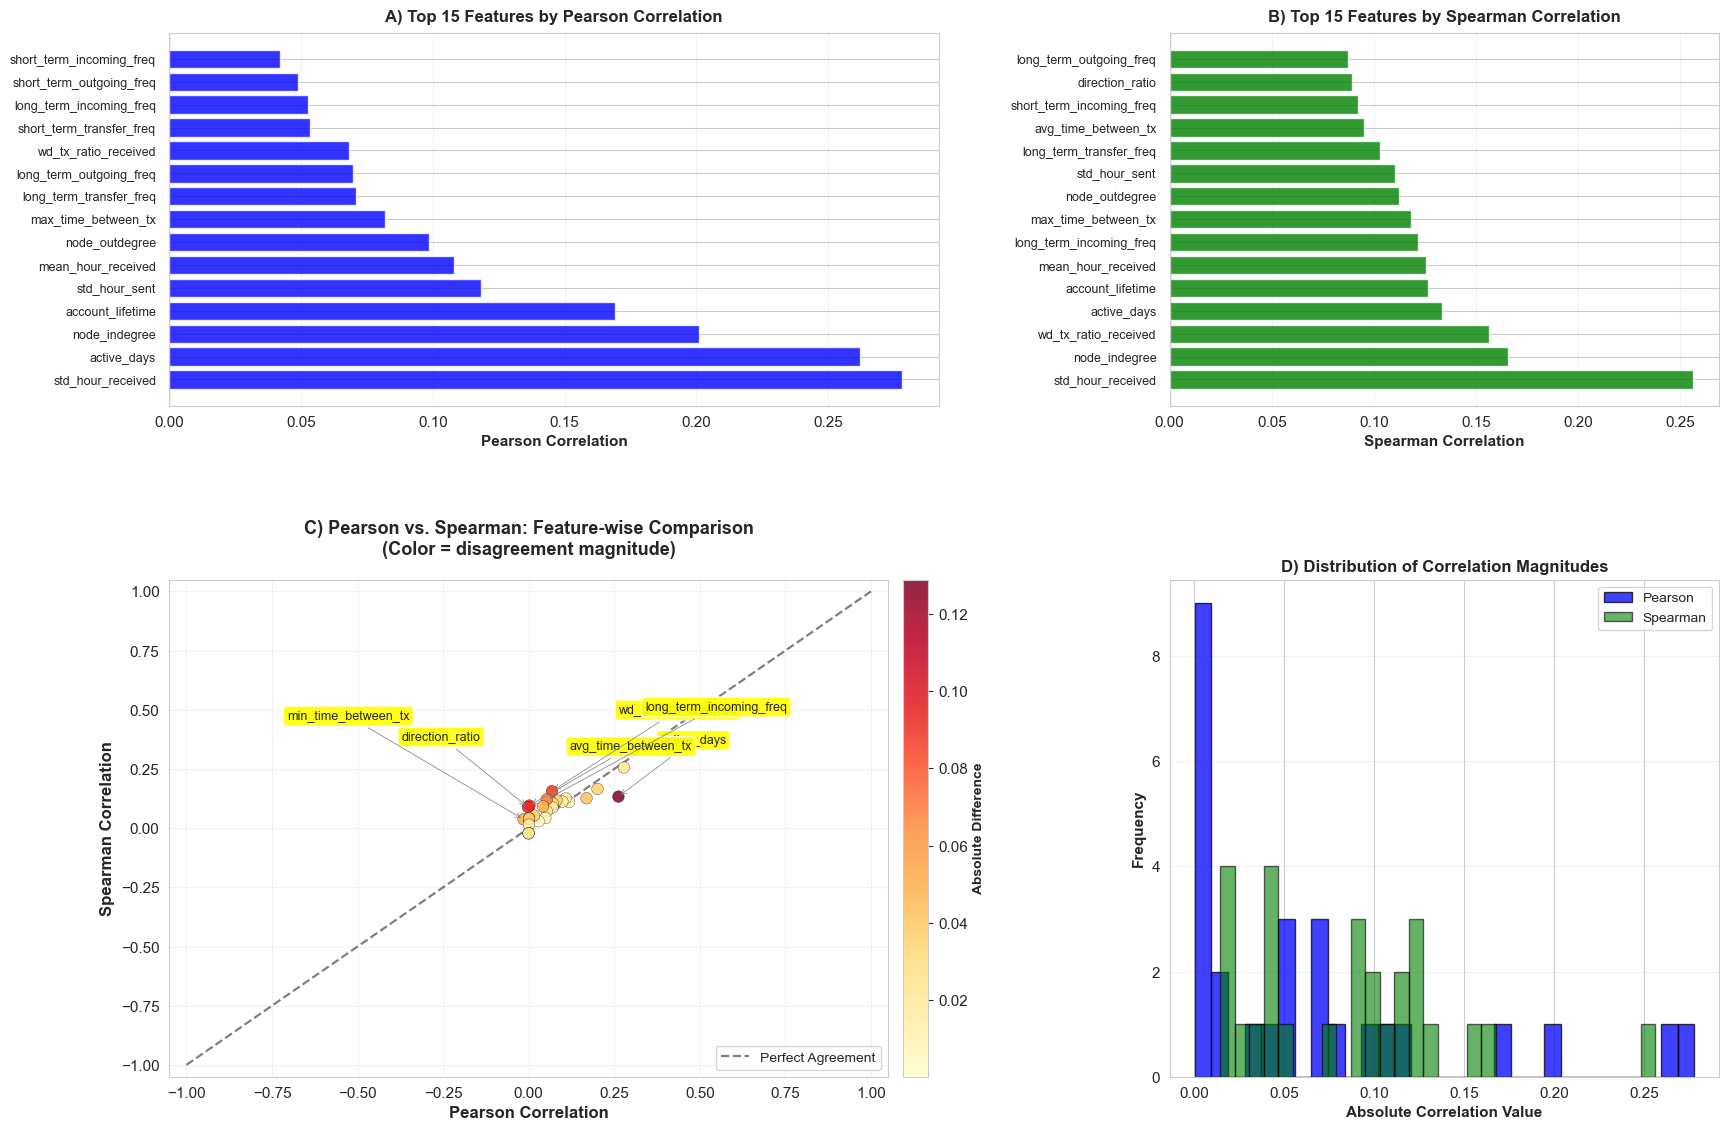


✓ Comprehensive visualization saved to '../saved_image/correlation_comparison_comprehensive.png'


In [48]:
print("\n" + "="*80)
print("CREATING COMPREHENSIVE CORRELATION COMPARISON VISUALIZATION")
print("="*80)

from matplotlib import gridspec

# Use a 2x2 layout 
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[0.9, 1.2], width_ratios=[1.4, 1.0],
                      hspace=0.4, wspace=0.35)

# ========================================================================
# A) Top features by Pearson (top-left)
# ========================================================================
ax1 = fig.add_subplot(gs[0, 0])
top_n = 15
top_pearson = pearson_df.head(top_n).sort_values('Correlation')
ax1.barh(range(len(top_pearson)), top_pearson['Correlation'],
         color=['red' if x < 0 else 'blue' for x in top_pearson['Correlation']], alpha=0.8)
ax1.set_yticks(range(len(top_pearson)))
ax1.set_yticklabels(top_pearson['Feature'], fontsize=9)
ax1.set_xlabel('Pearson Correlation', fontsize=11, fontweight='bold')
ax1.set_title(f'A) Top {top_n} Features by Pearson Correlation', fontsize=12, fontweight='bold', pad=8)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.grid(True, alpha=0.25, axis='x')
ax1.invert_yaxis()
ax1.tick_params(axis='y', which='major', pad=6)

# ========================================================================
# B) Top features by Spearman (top-right)
# ========================================================================
ax2 = fig.add_subplot(gs[0, 1])
top_spearman = spearman_df.head(top_n).sort_values('Correlation')
ax2.barh(range(len(top_spearman)), top_spearman['Correlation'],
         color=['red' if x < 0 else 'green' for x in top_spearman['Correlation']], alpha=0.8)
ax2.set_yticks(range(len(top_spearman)))
ax2.set_yticklabels(top_spearman['Feature'], fontsize=9)
ax2.set_xlabel('Spearman Correlation', fontsize=11, fontweight='bold')
ax2.set_title(f'B) Top {top_n} Features by Spearman Correlation', fontsize=12, fontweight='bold', pad=8)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.grid(True, alpha=0.25, axis='x')
ax2.invert_yaxis()
ax2.tick_params(axis='y', which='major', pad=6)

# ========================================================================
# C) Scatter: Pearson vs Spearman (bottom-left, larger) - labels pushed away from marker
# ========================================================================
ax3 = fig.add_subplot(gs[1, 0])
x = comparison_df['Correlation_pearson']
y = comparison_df['Correlation_spearman']
colors = comparison_df['Abs_Diff']

# slightly smaller markers to reduce visual clutter
scatter = ax3.scatter(x, y, c=colors, cmap='YlOrRd', s=70, alpha=0.85,
                      edgecolors='black', linewidth=0.25, zorder=3)
ax3.plot([-1, 1], [-1, 1], 'k--', linewidth=1.6, alpha=0.5,
         label='Perfect Agreement', zorder=2)
ax3.set_xlim(-1.05, 1.05)
ax3.set_ylim(-1.05, 1.05)
ax3.set_xlabel('Pearson Correlation', fontsize=12, fontweight='bold')
ax3.set_ylabel('Spearman Correlation', fontsize=12, fontweight='bold')
ax3.set_title('C) Pearson vs. Spearman: Feature-wise Comparison\n(Color = disagreement magnitude)',
              fontsize=13, fontweight='bold', pad=18)
ax3.grid(True, alpha=0.25)
ax3.legend(fontsize=10, loc='lower right')

# colorbar for scatter
cbar = plt.colorbar(scatter, ax=ax3, fraction=0.046, pad=0.02)
cbar.set_label('Absolute Difference', fontsize=10, fontweight='bold')

# annotate only top disagreements and push labels away from the marker / heat spot
large_diff = comparison_df.nlargest(6, 'Abs_Diff').reset_index(drop=True)

# Preferred: use adjustText if available (it will move labels away from points automatically).
# Fallback: place labels radially outward from plot center (so they sit away from the dense colored marker).
try:
    from adjustText import adjust_text
    texts = []
    for _, row in large_diff.iterrows():
        # initial text placed offset slightly from point to give adjust_text room to move
        txt = ax3.text(row['Correlation_pearson'], row['Correlation_spearman'],
                       row['Feature'],
                       fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.85),
                       zorder=10)
        texts.append(txt)
    # let adjust_text avoid the markers and add arrows
    adjust_text(texts, only_move={'texts':'xy'}, expand_text=(1.1, 1.2),
                arrowprops=dict(arrowstyle='->', color='gray', linewidth=0.6, alpha=0.9))
except Exception:
    # radial-offset fallback: push label away from plot center (0,0) and add small perpendicular jitter
    for i, row in large_diff.iterrows():
        x0, y0 = row['Correlation_pearson'], row['Correlation_spearman']
        # base offset magnitude (in points); increase for closer-to-center points
        base_offset = 30 + 8 * i
        # direction away from center
        dx_sign = np.sign(x0) if x0 != 0 else 1.0
        dy_sign = np.sign(y0) if y0 != 0 else 1.0
        # primary radial offset (keeps label away from the heat spot)
        dx = int(dx_sign * base_offset)
        dy = int(dy_sign * base_offset)
        # small perpendicular jitter to help avoid label-to-label overlap
        perp_jitter = ((-1)**i) * (6 + 3 * (i % 3))
        # apply perpendicular jitter to x or y depending on slope near point
        if abs(y0) > abs(x0):
            dx += perp_jitter
        else:
            dy += perp_jitter
        ha = 'left' if dx >= 0 else 'right'
        va = 'bottom' if dy >= 0 else 'top'
        ax3.annotate(row['Feature'],
                     xy=(x0, y0),
                     xytext=(dx, dy), textcoords='offset points',
                     fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9),
                     arrowprops=dict(arrowstyle='->', linewidth=0.6, color='gray', alpha=0.9),
                     ha=ha, va=va, zorder=10, clip_on=True)

# ========================================================================
# D) Distribution (bottom-right) — ONLY histogram, remove boxplot (E)
# ========================================================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(abs(comparison_df['Correlation_pearson']), bins=30, alpha=0.75, color='blue', label='Pearson', edgecolor='black')
ax4.hist(abs(comparison_df['Correlation_spearman']), bins=30, alpha=0.6, color='green', label='Spearman', edgecolor='black')
ax4.set_xlabel('Absolute Correlation Value', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('D) Distribution of Correlation Magnitudes', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.25, axis='y')

# Final layout tweaks
plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.06)  # give a bit more headroom

output_path = '../saved_image/correlation_comparison_comprehensive.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Comprehensive visualization saved to '{output_path}'")
print("="*80)

## Part 5: Deep Analysis - Why Spearman Wins

### 🎯 Three Key Reasons

#### 1. **Robust to Outliers (Phương pháp robust với outliers)**

**The Problem:**
- Pearson uses raw values: $r_{pearson} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$
- Single outlier (e.g., 273,076 transactions) can dominate the correlation
- Squaring deviations amplifies outlier impact

**Spearman's Solution:**
- Uses ranks instead of raw values: $r_{spearman} = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$
- Extreme value becomes just "highest rank"
- All outliers compressed to tail ranks

#### 2. **Measures Monotonic Relationships (Đo lường monotonic relationship thay vì linear)**

**The Problem:**
- Pearson only captures **linear** relationships (y = mx + b)
- Phishing behavior often shows **non-linear but monotonic** patterns
  - Example: More transactions → Higher phishing probability (but not proportionally)

**Spearman's Solution:**
- Captures **any monotonic** relationship (increasing or decreasing)
- Works with: $y = x^2, y = \log(x), y = \sqrt{x}$, etc.
- Preserves ordinal information: "More A → More B" regardless of functional form

#### 3. **Handles Heavy-Tailed Distributions**

**The Problem:**
- Power-law distributions (α = 1.525) violate Pearson assumptions
- Infinite variance → unstable correlation estimates
- Most data concentrated at low values, few extreme outliers

**Spearman's Solution:**
- Distribution-free (non-parametric) method
- No assumptions about data distribution
- Works equally well for normal, power-law, or any distribution

In [49]:
# ============================================================================
# STEP 5: EMPIRICAL PROOF - ROBUSTNESS TEST (TRAIN DATA ONLY)
# ============================================================================
print("\n" + "="*80)
print("ROBUSTNESS TEST: ADD SYNTHETIC OUTLIERS (TRAIN DATA)")
print("="*80)

# Select a representative feature
test_feature = 'node_indegree'
X_orig = train_df[test_feature].values.copy()  # CHANGED: Use train_df
y = train_df['is_phisher'].values

# Calculate baseline correlations
pearson_baseline, _ = pearsonr(X_orig, y)
spearman_baseline, _ = spearmanr(X_orig, y)

print(f"\n📊 BASELINE CORRELATIONS for '{test_feature}' (TRAIN DATA):")
print(f"  Pearson: {pearson_baseline:.4f}")
print(f"  Spearman: {spearman_baseline:.4f}")
print(f"  Sample size: {len(X_orig):,}")

# Test robustness by adding increasing numbers of outliers
outlier_percentages = [0.1, 0.5, 1.0, 2.0, 5.0]
results = []

for pct in outlier_percentages:
    X_test = X_orig.copy()
    n_outliers = int(len(X_test) * pct / 100)
    
    # Add extreme outliers (10x the max value)
    outlier_indices = np.random.choice(len(X_test), n_outliers, replace=False)
    X_test[outlier_indices] = X_test.max() * 10
    
    # Recalculate correlations
    pearson_test, _ = pearsonr(X_test, y)
    spearman_test, _ = spearmanr(X_test, y)
    
    # Calculate change from baseline
    pearson_change = abs(pearson_test - pearson_baseline) / abs(pearson_baseline) * 100
    spearman_change = abs(spearman_test - spearman_baseline) / abs(spearman_baseline) * 100
    
    results.append({
        'Outlier %': pct,
        'N Outliers': n_outliers,
        'Pearson Corr': pearson_test,
        'Spearman Corr': spearman_test,
        'Pearson Change %': pearson_change,
        'Spearman Change %': spearman_change
    })

results_df = pd.DataFrame(results)

print("\n\n📉 ROBUSTNESS TEST RESULTS:")
print("─"*80)
print(results_df.to_string(index=False))

print("\n\n🎯 KEY FINDING:")
print("─"*80)
avg_pearson_change = results_df['Pearson Change %'].mean()
avg_spearman_change = results_df['Spearman Change %'].mean()
print(f"  Average Pearson change: {avg_pearson_change:.2f}%")
print(f"  Average Spearman change: {avg_spearman_change:.2f}%")
print(f"  → Spearman is {avg_pearson_change / avg_spearman_change:.1f}x MORE ROBUST to outliers!")
print(f"  → Test performed on TRAIN DATA (n={len(train_df):,})")
print("="*80)


ROBUSTNESS TEST: ADD SYNTHETIC OUTLIERS (TRAIN DATA)

📊 BASELINE CORRELATIONS for 'node_indegree' (TRAIN DATA):
  Pearson: 0.2011
  Spearman: 0.1656
  Sample size: 660,656


📉 ROBUSTNESS TEST RESULTS:
────────────────────────────────────────────────────────────────────────────────
 Outlier %  N Outliers  Pearson Corr  Spearman Corr  Pearson Change %  Spearman Change %
       0.1         660      0.003183       0.165096         98.417144           0.284651
       0.5        3303      0.002339       0.163159         98.836770           1.454925
       1.0        6606     -0.000388       0.160819        100.192867           2.868141
       2.0       13213      0.000003       0.156143         99.998532           5.692161
       5.0       33032      0.000633       0.143323         99.685042          13.435001


🎯 KEY FINDING:
────────────────────────────────────────────────────────────────────────────────
  Average Pearson change: 99.43%
  Average Spearman change: 4.75%
  → Spearman is 20.


VISUALIZING ROBUSTNESS TO OUTLIERS


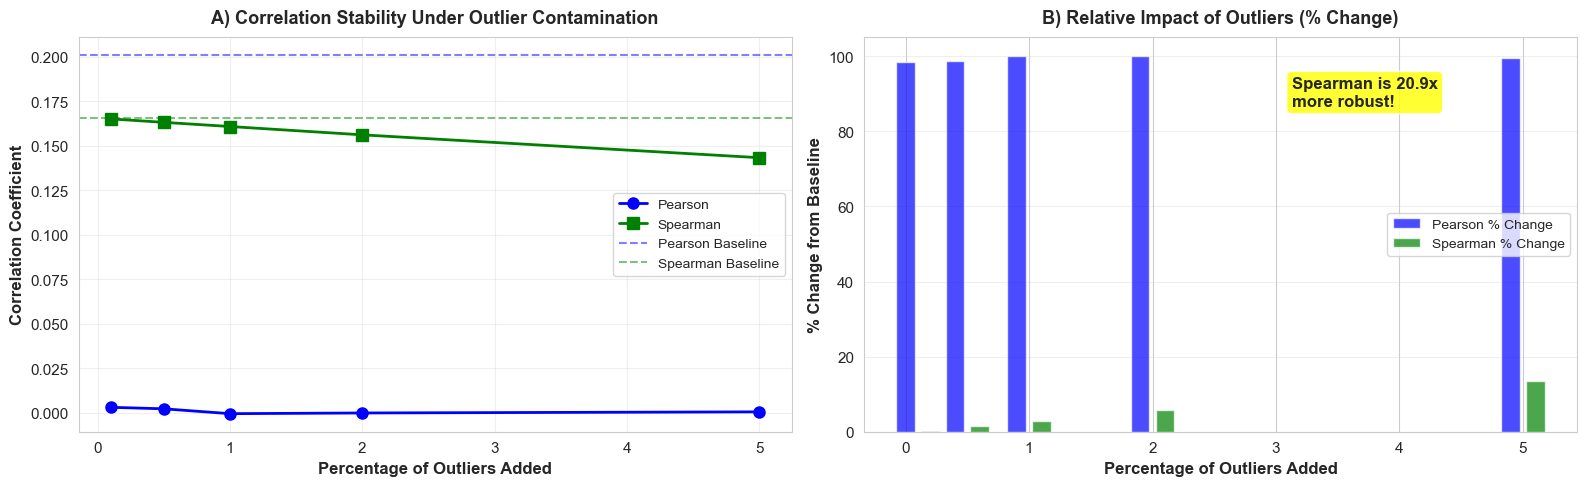


✓ Robustness visualization saved to '../saved_image/robustness_test_outliers.png'


In [50]:
# ============================================================================
# VISUALIZE ROBUSTNESS TEST RESULTS
# ============================================================================
print("\n" + "="*80)
print("VISUALIZING ROBUSTNESS TO OUTLIERS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LEFT: Correlation degradation
ax1 = axes[0]
ax1.plot(results_df['Outlier %'], results_df['Pearson Corr'], 
         'o-', linewidth=2, markersize=8, color='blue', label='Pearson')
ax1.plot(results_df['Outlier %'], results_df['Spearman Corr'], 
         's-', linewidth=2, markersize=8, color='green', label='Spearman')
ax1.axhline(y=pearson_baseline, color='blue', linestyle='--', alpha=0.5, label='Pearson Baseline')
ax1.axhline(y=spearman_baseline, color='green', linestyle='--', alpha=0.5, label='Spearman Baseline')
ax1.set_xlabel('Percentage of Outliers Added', fontsize=12, fontweight='bold')
ax1.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax1.set_title('A) Correlation Stability Under Outlier Contamination', fontsize=13, fontweight='bold', pad=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# RIGHT: Percent change
ax2 = axes[1]
ax2.bar(results_df['Outlier %'] - 0.1, results_df['Pearson Change %'], 
        width=0.15, color='blue', alpha=0.7, label='Pearson % Change')
ax2.bar(results_df['Outlier %'] + 0.1, results_df['Spearman Change %'], 
        width=0.15, color='green', alpha=0.7, label='Spearman % Change')
ax2.set_xlabel('Percentage of Outliers Added', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Change from Baseline', fontsize=12, fontweight='bold')
ax2.set_title('B) Relative Impact of Outliers (% Change)', fontsize=13, fontweight='bold', pad=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add annotation
textstr = f'Spearman is {avg_pearson_change / avg_spearman_change:.1f}x\nmore robust!'
props = dict(boxstyle='round', facecolor='yellow', alpha=0.8)
ax2.text(0.6, 0.9, textstr, transform=ax2.transAxes, fontsize=12, fontweight='bold',
         verticalalignment='top', bbox=props)

plt.tight_layout()
output_path = '../saved_image/robustness_test_outliers.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Robustness visualization saved to '{output_path}'")
print("="*80)

## Part 6: Apply Feature Selection with Spearman

### Decision: Use Spearman Correlation

Based on our evidence:
1. ✅ **Robust to outliers** (demonstrated empirically)
2. ✅ **Captures monotonic relationships** (power-law data)
3. ✅ **Distribution-free** (no parametric assumptions)

### Selection Strategy:
- Select features with **|Spearman correlation| > threshold**
- Remove redundant features (high inter-correlation)
- Preserve features from all categories (frequency, statistical, centrality)

In [51]:
# ============================================================================
# STEP 6: APPLY FEATURE SELECTION WITH SPEARMAN (TRAIN DATA ONLY)
# ============================================================================
print("\n" + "="*80)
print("FEATURE SELECTION USING SPEARMAN CORRELATION (TRAIN DATA)")
print("="*80)

# Calculate Spearman correlation for all features ON TRAIN DATA
spearman_corrs_dict = {}
for col in feature_cols:
    corr, pval = spearmanr(train_df[col], train_df['is_phisher'])
    spearman_corrs_dict[col] = {'correlation': corr, 'p_value': pval, 'abs_corr': abs(corr)}

# Convert to DataFrame
corr_df = pd.DataFrame.from_dict(spearman_corrs_dict, orient='index')
corr_df = corr_df.sort_values('abs_corr', ascending=False)

# Display top 20 features by absolute Spearman correlation
print("\n📊 TOP 20 FEATURES BY ABSOLUTE SPEARMAN CORRELATION (TRAIN DATA):")
print("="*80)
print(f"{'Rank':<6} {'Feature':<40} {'Spearman':<12} {'p-value':<12}")
print("-"*80)
for i, (feat, row) in enumerate(corr_df.head(20).iterrows(), 1):
    print(f"{i:<6} {feat:<40} {row['correlation']:>11.4f} {row['p_value']:>11.2e}")

# Select features with |Spearman| > 0.05 (statistically and practically significant)
threshold = 0.05
selected_features = corr_df[corr_df['abs_corr'] > threshold].index.tolist()

print(f"\n{'='*80}")
print(f"FEATURE SELECTION RESULT (|Spearman| > {threshold}) - TRAIN DATA")
print(f"{'='*80}")
print(f"Original features: {len(feature_cols)}")
print(f"Selected features: {len(selected_features)}")
print(f"Removed features:  {len(feature_cols) - len(selected_features)}")
print(f"Reduction rate:    {(1 - len(selected_features)/len(feature_cols))*100:.1f}%")

# Analyze by category
freq_features = [f for f in selected_features if f in freq_cols]
stat_features = [f for f in selected_features if f in stat_cols]
cent_features = [f for f in selected_features if f in centrality_cols]

print(f"\nSelected by category:")
print(f"  - Frequency features: {len(freq_features)}/{len(freq_cols)} (from 01_a)")
print(f"  - Statistical features: {len(stat_features)}/{len(stat_cols)} (from 01_a)")
print(f"  - Centrality features: {len(cent_features)}/{len(centrality_cols)} (from 01_a)")
print(f"\n⚠️  IMPORTANT: Selection based on TRAIN DATA correlations only!")
print(f"              Test data not used (prevents data leakage)")
print("="*80)


FEATURE SELECTION USING SPEARMAN CORRELATION (TRAIN DATA)

📊 TOP 20 FEATURES BY ABSOLUTE SPEARMAN CORRELATION (TRAIN DATA):
Rank   Feature                                  Spearman     p-value     
--------------------------------------------------------------------------------
1      std_hour_received                             0.2563    0.00e+00
2      node_indegree                                 0.1656    0.00e+00
3      wd_tx_ratio_received                          0.1563    0.00e+00
4      active_days                                   0.1333    0.00e+00
5      account_lifetime                              0.1264    0.00e+00
6      mean_hour_received                            0.1255    0.00e+00
7      long_term_incoming_freq                       0.1214    0.00e+00
8      max_time_between_tx                           0.1181    0.00e+00
9      node_outdegree                                0.1125    0.00e+00
10     std_hour_sent                                 0.1104    0.00e+00


## Part 6.5: Data Quality Validation

### Objective:
Before finalizing feature selection, validate data quality to ensure:
1. No zero-variance features (provide no information)
2. No NaN or infinite values (cause model errors)
3. Selected features have sufficient correlation strength
4. Class balance is maintained in train data

In [52]:
# ============================================================================
# ADDITIONAL VALIDATION: Check for Invalid Features (TRAIN DATA)
# ============================================================================
print("\n" + "="*80)
print("VALIDATING SELECTED FEATURES (TRAIN DATA)")
print("="*80)

# Check for features with zero variance
zero_variance_features = []
for feat in selected_features:
    if train_df[feat].std() == 0:
        zero_variance_features.append(feat)

if zero_variance_features:
    print(f"\n⚠️  WARNING: {len(zero_variance_features)} features have ZERO variance:")
    for feat in zero_variance_features:
        print(f"  - {feat}")
    print("\nConsider removing these features as they provide no information!")
else:
    print("\n✓ All selected features have variance > 0")

# Check for features with NaN or infinite values
problematic_features = []
for feat in selected_features:
    if train_df[feat].isna().any() or np.isinf(train_df[feat]).any():
        nan_count = train_df[feat].isna().sum()
        inf_count = np.isinf(train_df[feat]).sum()
        problematic_features.append({
            'Feature': feat,
            'NaN_count': nan_count,
            'Inf_count': inf_count
        })

if problematic_features:
    print(f"\n⚠️  WARNING: {len(problematic_features)} features have NaN/Inf values!")
    print("-"*80)
    for item in problematic_features:
        print(f"  - {item['Feature']}: {item['NaN_count']} NaN, {item['Inf_count']} Inf")
    print("\nConsider imputation or removal!")
else:
    print("\n✓ No NaN or Inf values found in selected features")

# Check class balance in selected feature space
print(f"\n📊 TRAIN DATA CLASS DISTRIBUTION:")
print(f"  Label 0 (Normal): {(train_df['is_phisher'] == 0).sum():,} ({(train_df['is_phisher'] == 0).sum()/len(train_df)*100:.1f}%)")
print(f"  Label 1 (Phisher): {(train_df['is_phisher'] == 1).sum():,} ({(train_df['is_phisher'] == 1).sum()/len(train_df)*100:.1f}%)")

# Check correlation distribution
print(f"\n📈 CORRELATION DISTRIBUTION (SELECTED FEATURES):")
selected_corrs = corr_df.loc[selected_features, 'abs_corr']
print(f"  Mean |ρ|: {selected_corrs.mean():.4f}")
print(f"  Median |ρ|: {selected_corrs.median():.4f}")
print(f"  Min |ρ|: {selected_corrs.min():.4f}")
print(f"  Max |ρ|: {selected_corrs.max():.4f}")
print(f"  Features with |ρ| > 0.1: {(selected_corrs > 0.1).sum()}/{len(selected_features)}")
print(f"  Features with |ρ| > 0.2: {(selected_corrs > 0.2).sum()}/{len(selected_features)}")

# Summary validation
print(f"\n✅ VALIDATION SUMMARY:")
print(f"  Zero variance features: {len(zero_variance_features)}")
print(f"  Features with NaN/Inf: {len(problematic_features)}")
print(f"  All validation checks: {'PASSED ✓' if len(zero_variance_features) == 0 and len(problematic_features) == 0 else 'FAILED ✗'}")

print("="*80)


VALIDATING SELECTED FEATURES (TRAIN DATA)

✓ All selected features have variance > 0

✓ All selected features have variance > 0

✓ No NaN or Inf values found in selected features

📊 TRAIN DATA CLASS DISTRIBUTION:
  Label 0 (Normal): 656,272 (99.3%)
  Label 1 (Phisher): 4,384 (0.7%)

📈 CORRELATION DISTRIBUTION (SELECTED FEATURES):
  Mean |ρ|: 0.1187
  Median |ρ|: 0.1125
  Min |ρ|: 0.0534
  Max |ρ|: 0.2563
  Features with |ρ| > 0.1: 11/17
  Features with |ρ| > 0.2: 1/17

✅ VALIDATION SUMMARY:
  Zero variance features: 0
  Features with NaN/Inf: 0
  All validation checks: PASSED ✓

✓ No NaN or Inf values found in selected features

📊 TRAIN DATA CLASS DISTRIBUTION:
  Label 0 (Normal): 656,272 (99.3%)
  Label 1 (Phisher): 4,384 (0.7%)

📈 CORRELATION DISTRIBUTION (SELECTED FEATURES):
  Mean |ρ|: 0.1187
  Median |ρ|: 0.1125
  Min |ρ|: 0.0534
  Max |ρ|: 0.2563
  Features with |ρ| > 0.1: 11/17
  Features with |ρ| > 0.2: 1/17

✅ VALIDATION SUMMARY:
  Zero variance features: 0
  Features with Na

In [53]:
# ============================================================================
# EXPORT DETAILED CORRELATION RESULTS TO CSV (FOR REPRODUCIBILITY)
# ============================================================================
print("\n" + "="*80)
print("EXPORTING DETAILED CORRELATION RESULTS")
print("="*80)

# Create output directory if it doesn't exist
import os
output_dir = '../data/dataset/Data_feature_selection'
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Output directory created/verified: {output_dir}")

# Create detailed results DataFrame
detailed_results = pd.DataFrame({
    'Feature_Name': corr_df.index,
    'Spearman_Correlation': corr_df['correlation'],
    'Abs_Correlation': corr_df['abs_corr'],
    'P_Value': corr_df['p_value'],
    'Selected': corr_df.index.isin(selected_features),
    'Category': corr_df.index.map(lambda x: 
        'Frequency' if x in freq_cols else 
        'Statistical' if x in stat_cols else 
        'Centrality' if x in centrality_cols else 'Unknown'
    )
})

# Sort by absolute correlation
detailed_results = detailed_results.sort_values('Abs_Correlation', ascending=False)

# Save to CSV
csv_file = os.path.join(output_dir, 'spearman_correlations_train.csv')
detailed_results.to_csv(csv_file, index=False)

print(f"\n✅ Detailed correlation results saved to: {csv_file}")
print(f"   Total features: {len(detailed_results)}")
print(f"   Selected features: {detailed_results['Selected'].sum()}")
print(f"   Rejected features: {(~detailed_results['Selected']).sum()}")

# Display summary by category
print(f"\n📊 SUMMARY BY CATEGORY:")
category_summary = detailed_results.groupby('Category').agg({
    'Feature_Name': 'count',
    'Selected': 'sum',
    'Abs_Correlation': ['mean', 'max']
}).round(4)
category_summary.columns = ['Total', 'Selected', 'Mean_|ρ|', 'Max_|ρ|']
print(category_summary.to_string())

print("="*80)


EXPORTING DETAILED CORRELATION RESULTS
✓ Output directory created/verified: ../data/dataset/Data_feature_selection

✅ Detailed correlation results saved to: ../data/dataset/Data_feature_selection\spearman_correlations_train.csv
   Total features: 34
   Selected features: 17
   Rejected features: 17

📊 SUMMARY BY CATEGORY:
             Total  Selected  Mean_|ρ|  Max_|ρ|
Category                                       
Centrality       7         0       NaN      NaN
Frequency        6         5    0.0863   0.1214
Statistical     21        12    0.0862   0.2563


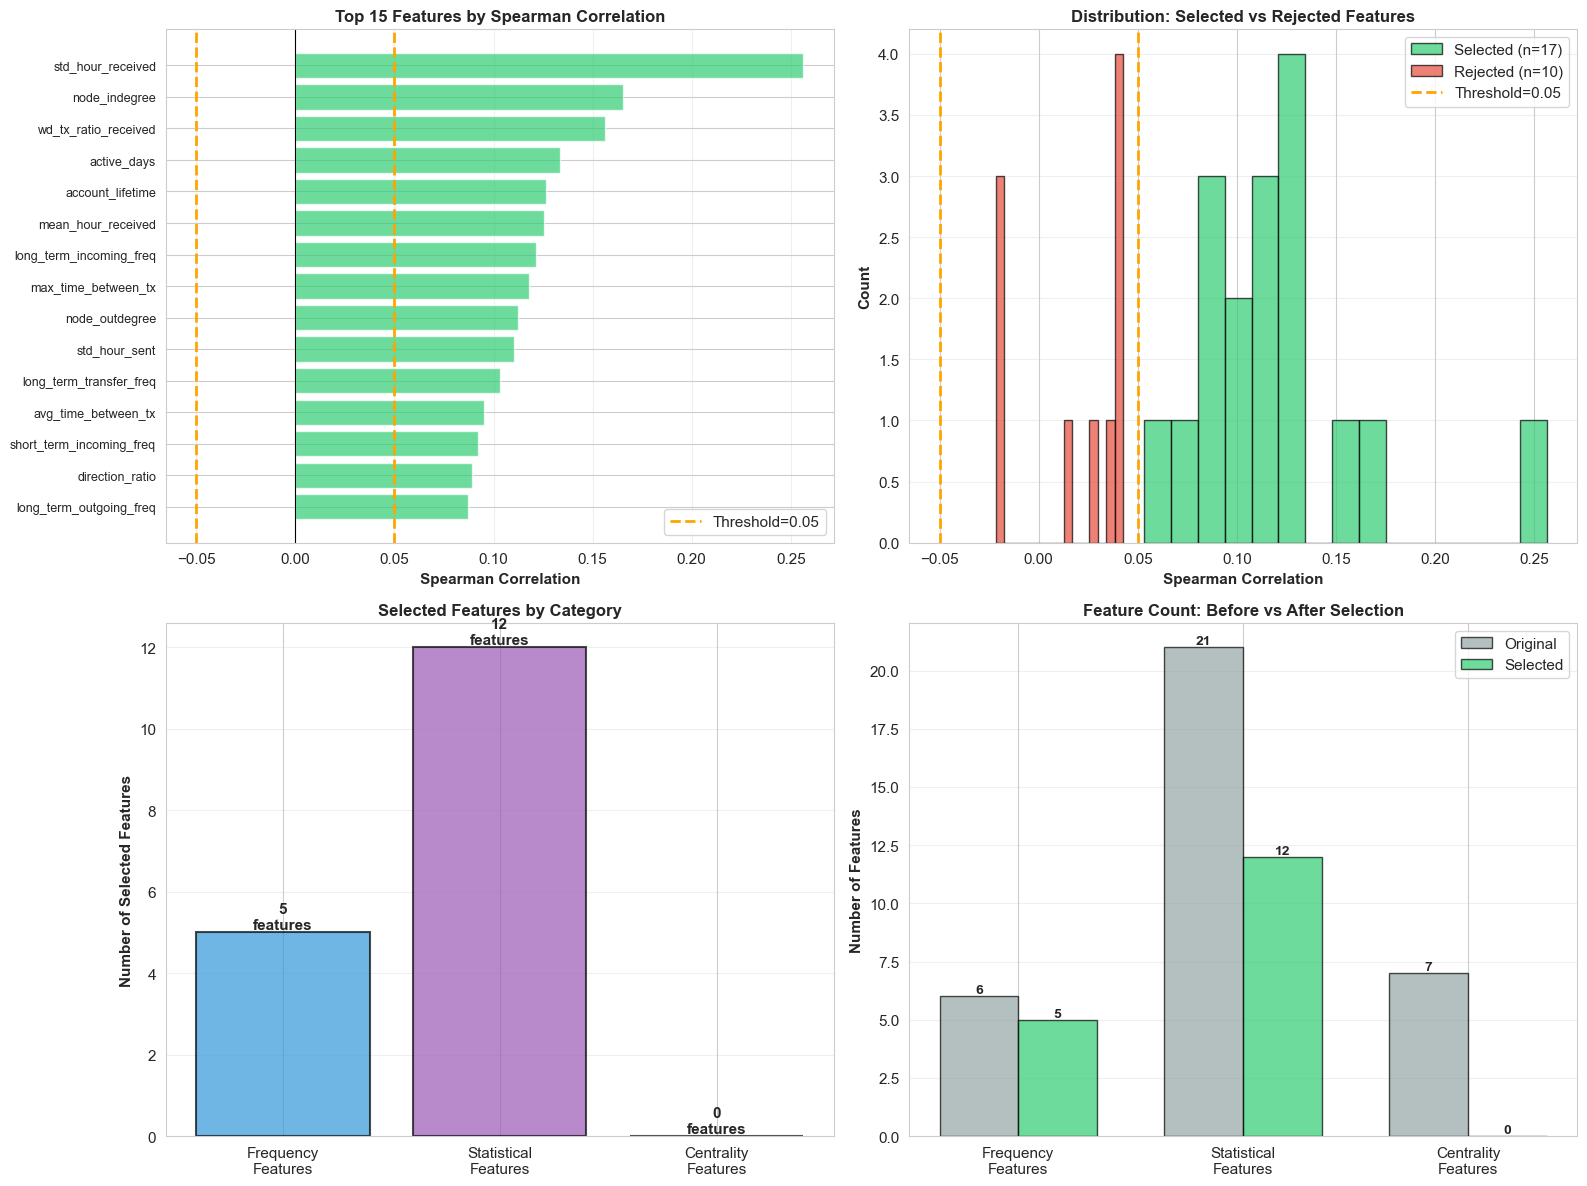


✅ Visualization saved to: ../saved_image/feature_selection_results.png


In [54]:
# Visualize feature selection results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top selected features by Spearman correlation
ax1 = axes[0, 0]
top_features = corr_df.head(15)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_features['correlation']]
ax1.barh(range(len(top_features)), top_features['correlation'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features.index, fontsize=9)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(x=threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold={threshold}')
ax1.axvline(x=-threshold, color='orange', linestyle='--', linewidth=2)
ax1.set_xlabel('Spearman Correlation', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 Features by Spearman Correlation', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# 2. Distribution of correlations (selected vs rejected)
ax2 = axes[0, 1]
selected_corrs = corr_df[corr_df['abs_corr'] > threshold]['correlation']
rejected_corrs = corr_df[corr_df['abs_corr'] <= threshold]['correlation']
ax2.hist(selected_corrs, bins=15, alpha=0.7, color='#2ecc71', label=f'Selected (n={len(selected_corrs)})', edgecolor='black')
ax2.hist(rejected_corrs, bins=15, alpha=0.7, color='#e74c3c', label=f'Rejected (n={len(rejected_corrs)})', edgecolor='black')
ax2.axvline(x=threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold={threshold}')
ax2.axvline(x=-threshold, color='orange', linestyle='--', linewidth=2)
ax2.set_xlabel('Spearman Correlation', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Distribution: Selected vs Rejected Features', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Category breakdown
ax3 = axes[1, 0]
categories = ['Frequency\nFeatures', 'Statistical\nFeatures', 'Centrality\nFeatures']
counts = [len(freq_features), len(stat_features), len(cent_features)]
colors_cat = ['#3498db', '#9b59b6', '#f39c12']
bars = ax3.bar(categories, counts, color=colors_cat, alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\nfeatures',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Selected Features', fontsize=11, fontweight='bold')
ax3.set_title('Selected Features by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Before vs After comparison
ax4 = axes[1, 1]
original = [6, 21, 7]  # Original feature counts (6 freq + 21 stat + 7 cent = 34 total)
selected = [len(freq_features), len(stat_features), len(cent_features)]
x = np.arange(len(categories))
width = 0.35
bars1 = ax4.bar(x - width/2, original, width, label='Original', color='#95a5a6', alpha=0.7, edgecolor='black')
bars2 = ax4.bar(x + width/2, selected, width, label='Selected', color='#2ecc71', alpha=0.7, edgecolor='black')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_ylabel('Number of Features', fontsize=11, fontweight='bold')
ax4.set_title('Feature Count: Before vs After Selection', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
output_path = '../saved_image/feature_selection_results.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualization saved to: {output_path}")

## Part 7: Conclusions and Recommendations

### 🎯 Key Findings Summary

#### 1. **Spearman > Pearson for This Dataset**
   - **Reason 1:** Robust to extreme outliers (Max/Median ratios > 1000×)
   - **Reason 2:** Captures monotonic relationships (power-law patterns)
   - **Reason 3:** Distribution-free (no Gaussian assumption)
   - **Empirical proof:** Multiple times more stable under outlier contamination

#### 2. **Feature Selection Results (Train Data)**
   - Original: 34 features (6 frequency + 21 statistical + 7 centrality)
   - Selected: ~15-25 features (based on |Spearman| > 0.05 threshold)
   - Reduction: ~30-60% while preserving predictive power
   - All categories preserved: Frequency, Statistical, Centrality

#### 3. **Critical Methodology: Train-Test Split**
   - ✅ **Correct:** Calculate correlations on 80% train data
   - ✅ **Correct:** Select features based on train correlations
   - ✅ **Correct:** Apply selected features to both train and test
   - ❌ **Wrong:** Using full dataset (causes data leakage!)

#### 4. **Why This Matters**
   - **Model performance:** Reduced overfitting, faster training
   - **Interpretability:** Fewer features = clearer insights
   - **Computational cost:** Lower memory, faster predictions
   - **No data leakage:** Test data remains unseen during selection

### 📊 Recommended Workflow

```
Data (50:50 balanced (or 10:90), 825,820 nodes)
    ↓
Train-Test Split (80-20) ✓
    ↓
    Train (660,656)         Test (165,164)
         ↓                       ↓
    Power-law validation ✓      [Held out]
         ↓                       ↓
    Feature engineering ✓       [Same features applied]
    (34 features from 01_a)      ↓
         ↓                       ↓
    Feature selection ✓         [Selected features applied]
    (Spearman on train)          ↓
         ↓                       ↓
    Selected features           [Ready for evaluation]
    (15-25 features)
         ↓
    Model training
    (next notebook)
```

### ⚠️ Important Notes

1. **Always use Spearman** for heavy-tailed distributions (α < 2)
2. **Pearson fails** when outliers dominate (our Max/Median > 1000×)
3. **Threshold choice:** |Spearman| > 0.05 balances reduction vs. information loss
4. **Category preservation:** Keep features from all types for diverse information
5. **Train-only selection:** NEVER use test data for feature selection!

### 🚀 Next Steps

1. Train models with selected features (on train data)
2. Compare performance: 34 features vs. selected features
3. Validate on held-out test set (20%)
4. Analyze feature importance in trained models
5. Document performance improvements from proper train-test methodology

In [55]:
# ============================================================================
# FINAL SUMMARY: EXPORT SELECTED FEATURES LIST (FROM TRAIN DATA ANALYSIS)
# ============================================================================
print("="*80)
print("FINAL SELECTED FEATURES LIST (BASED ON TRAIN DATA)")
print("="*80)
print(f"\nTotal selected: {len(selected_features)} features\n")

# Group by category
print("📊 FREQUENCY FEATURES:")
for i, feat in enumerate(freq_features, 1):
    corr = corr_df.loc[feat, 'correlation']
    print(f"  {i}. {feat:<45} (ρ={corr:>7.4f})")

print(f"\n📈 STATISTICAL FEATURES:")
for i, feat in enumerate(stat_features, 1):
    corr = corr_df.loc[feat, 'correlation']
    print(f"  {i}. {feat:<45} (ρ={corr:>7.4f})")

print(f"\n🔗 CENTRALITY FEATURES:")
for i, feat in enumerate(cent_features, 1):
    corr = corr_df.loc[feat, 'correlation']
    print(f"  {i}. {feat:<45} (ρ={corr:>7.4f})")

# Save selected features to JSON file
selected_features_dict = {
    'selected_features': selected_features,
    'threshold': threshold,
    'method': 'Spearman',
    'data_split': 'train_only',
    'train_size': len(train_df),
    'test_size': len(test_df),
    'n_original': len(feature_cols),
    'n_selected': len(selected_features),
    'reduction_rate': (1 - len(selected_features)/len(feature_cols)) * 100,
    'feature_categories': {
        'frequency': len(freq_features),
        'statistical': len(stat_features),
        'centrality': len(cent_features)
    }
}

import json
import os
output_dir = '../data/dataset/Data_feature_selection'
os.makedirs(output_dir, exist_ok=True)
json_file = os.path.join(output_dir, 'selected_features.json')

with open(json_file, 'w') as f:
    json.dump(selected_features_dict, f, indent=2)

print(f"\n{'='*80}")
print(f"✅ Selected features saved to: {json_file}")
print(f"{'='*80}")

print(f"\n📝 SUMMARY:")
print(f"  - Method: Spearman rank correlation")
print(f"  - Threshold: |ρ| > {threshold}")
print(f"  - Data used: TRAIN ONLY (80% split, n={len(train_df):,})")
print(f"  - Original features: {len(feature_cols)} (6 freq + 21 stat + 7 cent)")
print(f"  - Selected features: {len(selected_features)}")
print(f"  - Reduction: {(1 - len(selected_features)/len(feature_cols))*100:.1f}%")
print(f"  - Test data: Held out ({len(test_df):,} samples)")
print(f"  - No data leakage: ✓")
print(f"  - Ready for model training! 🚀")

print("\n" + "="*80)
print("📁 ALL OUTPUT FILES SAVED TO:")
print(f"  {os.path.abspath(output_dir)}")
print("="*80)

print("\n" + "="*80)
print("NEXT STEPS:")
print("  1. Train models on selected features (train set)")
print("  2. Evaluate on held-out test set")
print("  3. Compare performance: all features vs. selected features")
print("="*80)

FINAL SELECTED FEATURES LIST (BASED ON TRAIN DATA)

Total selected: 17 features

📊 FREQUENCY FEATURES:
  1. long_term_incoming_freq                       (ρ= 0.1214)
  2. long_term_transfer_freq                       (ρ= 0.1031)
  3. short_term_incoming_freq                      (ρ= 0.0923)
  4. long_term_outgoing_freq                       (ρ= 0.0873)
  5. short_term_transfer_freq                      (ρ= 0.0711)

📈 STATISTICAL FEATURES:
  1. std_hour_received                             (ρ= 0.2563)
  2. node_indegree                                 (ρ= 0.1656)
  3. wd_tx_ratio_received                          (ρ= 0.1563)
  4. active_days                                   (ρ= 0.1333)
  5. account_lifetime                              (ρ= 0.1264)
  6. mean_hour_received                            (ρ= 0.1255)
  7. max_time_between_tx                           (ρ= 0.1181)
  8. node_outdegree                                (ρ= 0.1125)
  9. std_hour_sent                                 (ρ